In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Bengaluru_House_Data.csv')

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.shape

(13320, 9)

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [9]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [11]:
# Drop useless columns
df2 = df.drop(['area_type', 'society', 'availability'], axis='columns')

# Impute balcony (weak feature, moderate missing %) instead of dropping rows
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].median())

# Drop rows only for small, important-column nulls (location, size, bath)
df3 = df2.dropna().copy()

# Convert '2 BHK' / '4 Bedroom' -> 2, 4
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

# Inspect total_sqft mess before converting
df3[~df3['total_sqft'].apply(lambda x: x.replace('.','',1).isdigit())].head(10)

,location,size,total_sqft,bath,balcony,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,2.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,0.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,0.0,445.000,4


In [12]:
# what was the median that got used for imputation?
print(df2['balcony'].median())

# how many rows actually have balcony == 0 in the ORIGINAL data (before your dropna/cleaning)?
print((df['balcony'] == 0).sum())

2.0
1029


In [13]:
def convert_sqft(x):
    x = x.strip()

    # Case 1: range like "2100 - 2850"
    if '-' in x:
        tokens = x.split('-')
        try:
            return (float(tokens[0].strip()) + float(tokens[1].strip())) / 2
        except:
            return None

    # Case 2: Sq. Meter -> convert to sqft
    if 'Sq. Meter' in x:
        try:
            num = float(x.replace('Sq. Meter', '').strip())
            return num * 10.7639
        except:
            return None

    # Case 3: unknown/rare units like Perch, Acres, Guntha -> too risky to guess, drop
    try:
        return float(x)
    except:
        return None  # will become NaN, drop later

df3['total_sqft'] = df3['total_sqft'].apply(convert_sqft)

# check how many became NaN (unrecoverable / dropped)
print(df3['total_sqft'].isnull().sum())

df3 = df3.dropna(subset=['total_sqft']).copy()

29


In [14]:
df3.isnull().sum()
df3.shape
df3.dtypes

,0
location,object
size,object
total_sqft,float64
bath,float64
balcony,float64
price,float64
bhk,int64


In [18]:
df3.head()

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2


In [19]:
df4 = df3.drop('size', axis='columns').copy()

In [20]:
print(df4.shape)
print(df4.columns)

(13217, 6)
Index(['location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk'], dtype='object')


In [21]:
print(df4.duplicated().sum())
df4 = df4.drop_duplicates().copy()
print(df4.shape)

751
(12466, 6)


In [22]:
df4['location'] = df4['location'].apply(lambda x: x.strip())

In [23]:
print(df4['location'].nunique())

1287


In [24]:
location_counts = df4['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df4['location'] = df4['location'].apply(lambda x: 'other' if x in rare_locations else x)

print(df4['location'].nunique())

232


In [25]:
df4['price_per_sqft'] = df4['price'] * 100000 / df4['total_sqft']

In [26]:
location_counts = df4['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df4['location'] = df4['location'].apply(lambda x: 'other' if x in rare_locations else x)

print(df4['location'].nunique())  # should drop to roughly 240-ish

232


In [27]:
print(df4.columns)
print(df4[['price', 'total_sqft', 'price_per_sqft']].head())

Index(['location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk',
       'price_per_sqft'],
      dtype='object')
    price  total_sqft  price_per_sqft
0   39.07      1056.0     3699.810606
1  120.00      2600.0     4615.384615
2   62.00      1440.0     4305.555556
3   95.00      1521.0     6245.890861
4   51.00      1200.0     4250.000000


In [28]:
# 5a. Remove sqft-per-bhk sanity violations
df5 = df4[~(df4['total_sqft'] / df4['bhk'] < 300)].copy()
print(df5.shape)

# 5b. Remove price_per_sqft outliers, per location
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = subdf.price_per_sqft.mean()
        st = subdf.price_per_sqft.std()
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df5 = remove_pps_outliers(df5)
print(df5.shape)

(11735, 7)
(9707, 7)


In [29]:
# 5c. Remove bathroom count anomalies
df5 = df5[df5.bath < df5.bhk + 2].copy()
print(df5.shape)

(9608, 7)


In [31]:
df5

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,1.0,428.00,4,15017.543860
1,1st Block Jayanagar,1630.0,3.0,2.0,194.00,3,11901.840491
2,1st Block Jayanagar,1875.0,2.0,3.0,235.00,3,12533.333333
3,1st Block Jayanagar,1200.0,2.0,0.0,130.00,3,10833.333333
4,1st Block Jayanagar,1235.0,2.0,2.0,148.00,2,11983.805668
...,...,...,...,...,...,...,...
9702,other,1095.0,2.0,1.0,57.00,2,5205.479452
9703,other,812.0,1.0,0.0,26.00,1,3201.970443
9704,other,1440.0,2.0,2.0,63.93,3,4439.583333
9705,other,1075.0,2.0,2.0,48.00,2,4465.116279


In [32]:
dummies = pd.get_dummies(df5['location'])
df6 = pd.concat([df5, dummies.drop('other', axis='columns')], axis='columns')
df6 = df6.drop('location', axis='columns')
print(df6.shape)
print(df6.columns)

(9608, 237)
Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft',
       '1st Block Jayanagar', '1st Phase JP Nagar', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='object', length=237)


In [36]:
df6

,total_sqft,bath,balcony,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Stage Nagarbhavi,5th Block Hbr Layout,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,1.0,428.00,4,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,2.0,194.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3.0,235.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,0.0,130.00,3,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2.0,148.00,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9702,1095.0,2.0,1.0,57.00,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9703,812.0,1.0,0.0,26.00,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9704,1440.0,2.0,2.0,63.93,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9705,1075.0,2.0,2.0,48.00,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [37]:
from sklearn.model_selection import train_test_split

X = df6.drop('price', axis='columns')
y = df6['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(7686, 235) (1922, 235)


In [38]:
!pip install xgboost -q

In [39]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'{name} trained')

Linear Regression trained
Ridge trained
Lasso trained
Decision Tree trained
Random Forest trained
XGBoost trained


In [40]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse})

results_df = pd.DataFrame(results).sort_values('R2 Score', ascending=False)
print(results_df)

               Model  R2 Score       RMSE
0  Linear Regression  0.756938  44.725187
1              Ridge  0.753089  45.077973
4      Random Forest  0.675395  51.685831
5            XGBoost  0.632140  55.021885
2              Lasso  0.620388  55.893836
3      Decision Tree  0.605030  57.013285


In [41]:
for name in ['Decision Tree', 'Random Forest', 'XGBoost']:
    train_r2 = r2_score(y_train, trained_models[name].predict(X_train))
    test_r2 = r2_score(y_test, trained_models[name].predict(X_test))
    print(f'{name}: Train R2 = {train_r2:.3f}, Test R2 = {test_r2:.3f}')

Decision Tree: Train R2 = 0.984, Test R2 = 0.605
Random Forest: Train R2 = 0.958, Test R2 = 0.675
XGBoost: Train R2 = 0.861, Test R2 = 0.632


In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

tuned_models = {
    'Decision Tree (tuned)': DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
    'Random Forest (tuned)': RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42),
    'XGBoost (tuned)': XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42)
}

for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f'{name}: Train R2 = {train_r2:.3f}, Test R2 = {test_r2:.3f}')

Decision Tree (tuned): Train R2 = 0.760, Test R2 = 0.740
Random Forest (tuned): Train R2 = 0.769, Test R2 = 0.682
XGBoost (tuned): Train R2 = 0.818, Test R2 = 0.616


In [43]:
from sklearn.model_selection import GridSearchCV

# Random Forest tuning
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_leaf': [1, 5, 10]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print('Best RF params:', rf_grid.best_params_)
print('Best RF CV score:', rf_grid.best_score_)
print('RF test score:', r2_score(y_test, rf_grid.best_estimator_.predict(X_test)))

# XGBoost tuning
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=5, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
print('Best XGB params:', xgb_grid.best_params_)
print('Best XGB CV score:', xgb_grid.best_score_)
print('XGB test score:', r2_score(y_test, xgb_grid.best_estimator_.predict(X_test)))

KeyboardInterrupt: 

In [44]:
from sklearn.model_selection import RandomizedSearchCV

# Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_leaf': [1, 5, 10]
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_params,
                                 n_iter=15, cv=3, scoring='r2', n_jobs=-1, random_state=42)
rf_search.fit(X_train, y_train)
print('Best RF params:', rf_search.best_params_)
print('RF test score:', r2_score(y_test, rf_search.best_estimator_.predict(X_test)))

# XGBoost
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42), xgb_params,
                                  n_iter=15, cv=3, scoring='r2', n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)
print('Best XGB params:', xgb_search.best_params_)
print('XGB test score:', r2_score(y_test, xgb_search.best_estimator_.predict(X_test)))

Best RF params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 12}
RF test score: 0.6852951883452447
Best XGB params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
XGB test score: 0.6321623612983929


In [49]:
final_models = {
    'Linear Regression': trained_models['Linear Regression'],
    'Ridge': trained_models['Ridge'],
    'Lasso': trained_models['Lasso'],
    'Decision Tree (tuned)': tuned_models['Decision Tree (tuned)'],
    'Random Forest (tuned)': rf_search.best_estimator_,
    'XGBoost (tuned)': xgb_search.best_estimator_
}

final_results = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    final_results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse})

final_results_df = pd.DataFrame(final_results).sort_values('R2 Score', ascending=False)
print(final_results_df)

                   Model  R2 Score       RMSE
0      Linear Regression  0.756938  44.725187
1                  Ridge  0.753089  45.077973
3  Decision Tree (tuned)  0.739694  46.284528
4  Random Forest (tuned)  0.685295  50.891539
5        XGBoost (tuned)  0.632162  55.020176
2                  Lasso  0.620388  55.893836


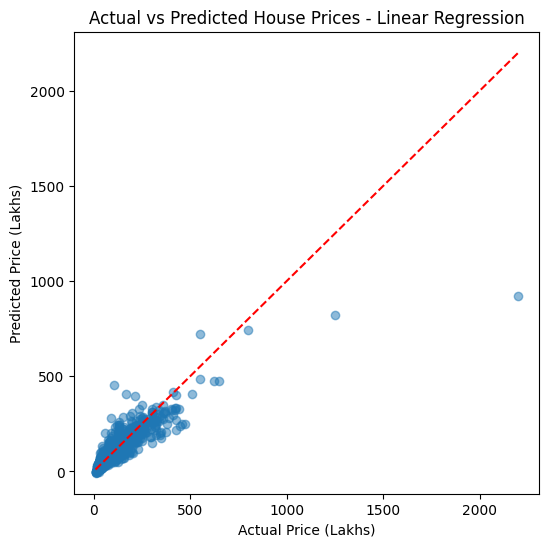

In [45]:
import matplotlib.pyplot as plt

best_model = trained_models['Linear Regression']
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted House Prices - Linear Regression')
plt.show()

In [46]:
def predict_price(location, total_sqft, bath, balcony, bhk):
    # start with a row of all zeros matching your training columns
    x = pd.Series(0, index=X.columns)

    x['total_sqft'] = total_sqft
    x['bath'] = bath
    x['balcony'] = balcony
    x['bhk'] = bhk

    if location in X.columns:
        x[location] = 1
    else:
        print(f"Warning: '{location}' not found in trained locations, treating as 'other'")

    prediction = best_model.predict([x])[0]
    return prediction

In [47]:
price = predict_price('Whitefield', total_sqft=1200, bath=2, balcony=1, bhk=2)
print(f'Predicted price: ₹{price:.2f} lakhs')

Predicted price: ₹64.09 lakhs


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
